In [319]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [320]:
def AND(x1, x2, x3=1):
    X = np.array([x1, x2])
    w = np.array([0.5, 0.5])
    b = x3 * (-0.7)
    y = np.dot(X, w)+b
    if y <= 0:
        return 0
    else:
        return 1

def OR(x1, x2, x3=1):
    x=np.array([x1, x2])
    w=np.array([0.5, 0.5])
    b = x3 * (-0.2)
    z1 = np.dot(x,w)+b
    if z1 <= 0:
        return 0
    else:
        return 1

def NAND(x1, x2, x3=1):
    x=np.array([x1, x2])
    w=np.array([-0.5, -0.5])
    b = x3*0.7
    z1 = np.dot(x,w)+b
    if z1 <= 0:
        return 0
    else:
        return 1

def XOR(x1, x2):
    s1 = NAND(x1, x2)
    s2 = OR(x1, x2)
    y = AND(s1, s2)
    return y

In [321]:
XOR(1, 1)

0

# 퍼셉트론

$$
y=
\begin{cases}
0, & (x_1w_1+x_2w_2 \leq \theta) \\
1, & (x_1w_1+x_2w_2 \gt \theta)
\end{cases}
\\
\quad \\
\\
b_1 = -\theta
\\
\quad \\
\\
y=
\begin{cases}
0, & (b_1 + x_1w_1+x_2w_2 \leq 0) \\
1, & (b_1 + x_1w_1+x_2w_2 \gt 0)
\end{cases}
\\
\quad \\
\\
a = b_1 + x_1w_1+x_2w_2
\\
\quad \\
\\
h(a) =
\begin{cases}
0, & (a\leq 0) \\
1, & (a \gt 0)
\end{cases}\\
\quad \\
\quad \\
\\
y = h(a) \\
$$

h(a) : 활성화 함수

# 활성화 함수

In [322]:
def step_func(x):
    if x >= 0:
        return 1
    else:
        return 0

In [323]:
step_func(0.1), step_func(-1.7)

(1, 0)

In [324]:
x = np.arange(-5, 5, 0.1)
x

array([-5.00000000e+00, -4.90000000e+00, -4.80000000e+00, -4.70000000e+00,
       -4.60000000e+00, -4.50000000e+00, -4.40000000e+00, -4.30000000e+00,
       -4.20000000e+00, -4.10000000e+00, -4.00000000e+00, -3.90000000e+00,
       -3.80000000e+00, -3.70000000e+00, -3.60000000e+00, -3.50000000e+00,
       -3.40000000e+00, -3.30000000e+00, -3.20000000e+00, -3.10000000e+00,
       -3.00000000e+00, -2.90000000e+00, -2.80000000e+00, -2.70000000e+00,
       -2.60000000e+00, -2.50000000e+00, -2.40000000e+00, -2.30000000e+00,
       -2.20000000e+00, -2.10000000e+00, -2.00000000e+00, -1.90000000e+00,
       -1.80000000e+00, -1.70000000e+00, -1.60000000e+00, -1.50000000e+00,
       -1.40000000e+00, -1.30000000e+00, -1.20000000e+00, -1.10000000e+00,
       -1.00000000e+00, -9.00000000e-01, -8.00000000e-01, -7.00000000e-01,
       -6.00000000e-01, -5.00000000e-01, -4.00000000e-01, -3.00000000e-01,
       -2.00000000e-01, -1.00000000e-01, -1.77635684e-14,  1.00000000e-01,
        2.00000000e-01,  

In [325]:
# numpy가 받아들이는걸로 변경해야함
# step_func(x)

In [326]:
def step_func(x):
    y = x > 0
    y = y.astype(int)
    return y

In [327]:
step_func(x)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

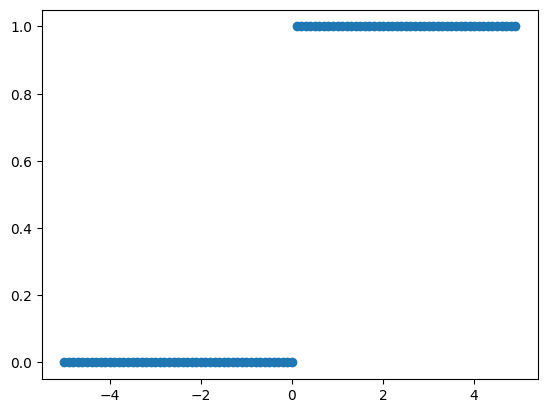

In [328]:
plt.scatter(x, step_func(x))

시그모이드 함수

$$
\begin{equation*}
h(x) = \frac{1}{1 + e^{-x}}
\end{equation*}
$$

In [329]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [330]:
x = np.array([-1.0, 1.0, 2.0])
sigmoid(x)

array([0.26894142, 0.73105858, 0.88079708])

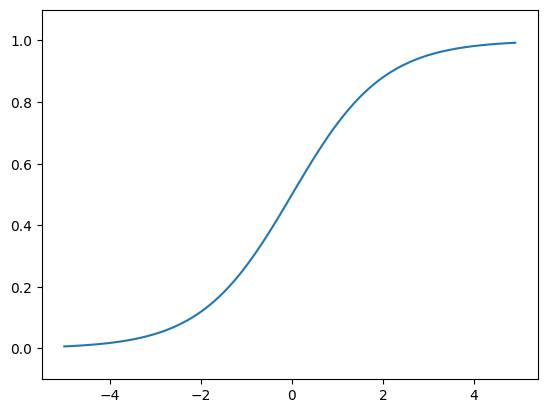

In [331]:
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-0.1, 1.1)
plt.show()

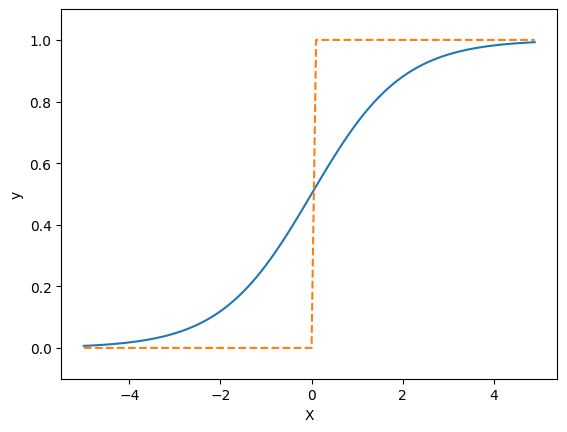

In [332]:
from matplotlib.lines import lineStyles
x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)
y2 = step_func(x)
plt.plot(x, y, label='sigmoid')
plt.plot(x, y2, label='step_func', linestyle='--')
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(-0.1, 1.1)
plt.show()

In [333]:
def relu(x):
    return np.maximum(0, x)

In [334]:
x = np.arange(-15, 15, 0.1)
y = relu(x)

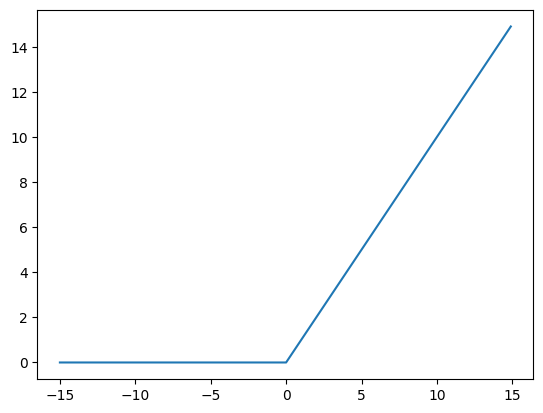

In [335]:
plt.plot(x, y)

In [336]:
def identity_function(x):
    return x

def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def step_function(x):
    return np.array(x > 0, dtype=np.int)

In [337]:
X = np.array([1.0, 0.5])
W1 = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
B1 = np.array([0.1, 0.2, 0.3])
A1 = np.dot(X, W1) + B1
Z1 = sigmoid(A1)

In [338]:
A1

array([0.3, 0.7, 1.1])

In [339]:
Z1

array([0.57444252, 0.66818777, 0.75026011])

In [340]:
W2 = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
B2 = np.array([0.1, 0.2])
A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)

In [341]:
A2

array([0.51615984, 1.21402696])

In [342]:
Z2

array([0.62624937, 0.7710107 ])

In [343]:
W1.shape

(2, 3)

In [344]:
Z1.shape

(3,)

In [345]:
W2.shape

(3, 2)

In [346]:
W3 = np.array([[0.1, 0.3], [0.2, 0.4]])
B3 = np.array([0.1, 0.2])
A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)

In [347]:
X.shape, W1.shape, Z1.shape, W2.shape, Z2.shape, W3.shape, Y.shape

((2,), (2, 3), (3,), (3, 2), (2,), (2, 2), (2,))

In [348]:
W1.shape, W2.shape, W3.shape

((2, 3), (3, 2), (2, 2))

In [349]:
def init_network():
    network = {}
    network['W1'] = np.array([[0.1, 0.3, 0.5], [0.2, 0.4, 0.6]])
    network['B1'] = np.array([0.1, 0.2, 0.3])
    network['W2'] = np.array([[0.1, 0.4], [0.2, 0.5], [0.3, 0.6]])
    network['B2'] = np.array([0.1, 0.2])
    network['W3'] = np.array([[0.1, 0.3], [0.2, 0.4]])
    network['B3'] = np.array([0.1, 0.2])
    return network

In [350]:
# 순전파로 하는 모델
def forward(network, X):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    B1, B2, B3 = network['B1'], network['B2'], network['B3']

    A1 = np.dot(X, W1) + B1
    Z1 = sigmoid(A1)
    A2 = np.dot(Z1, W2) + B2
    Z2 = sigmoid(A2)
    A3 = np.dot(Z2, W3) + B3
    Y = identity_function(A3)

    return Y

In [351]:
network = init_network()

In [352]:
x = np.array([1.0, 0.5])
y = forward(network, x)

x가 바뀔때

In [353]:
y

array([0.31682708, 0.69627909])

In [354]:
def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

In [355]:
a = np.array([0.3, 2.9, 4.0])
exp_a = np.exp(a)
exp_a
sum_exp_a = np.sum(exp_a)
sum_exp_a
y = exp_a / sum_exp_a

In [356]:
y

array([0.01821127, 0.24519181, 0.73659691])

In [357]:
np.sum(y)

np.float64(1.0)

In [358]:
# 값이 너무 커서 나타나지 않음
a = np.array([1010, 1000, 990])
np.exp(a) / np.sum(np.exp(a))

/tmp/ipykernel_11639/417058852.py:3: RuntimeWarning: overflow encountered in exp
  np.exp(a) / np.sum(np.exp(a))
/tmp/ipykernel_11639/417058852.py:3: RuntimeWarning: invalid value encountered in divide
  np.exp(a) / np.sum(np.exp(a))


array([nan, nan, nan])

In [359]:
k = a - np.max(a)
np.exp(k) / np.sum(np.exp(k))

array([9.99954600e-01, 4.53978686e-05, 2.06106005e-09])

In [360]:
k

array([  0, -10, -20])

In [361]:
x = np.array([2, 3, 4])
np.exp(x) / np.sum(np.exp(x))

array([0.09003057, 0.24472847, 0.66524096])

In [362]:
np.exp(x - np.max(x) / np.sum(np.exp(x - np.max(x))))

array([0.51635342, 1.40359412, 3.8153644 ])

In [363]:
x-np.max(x)

array([-2, -1,  0])

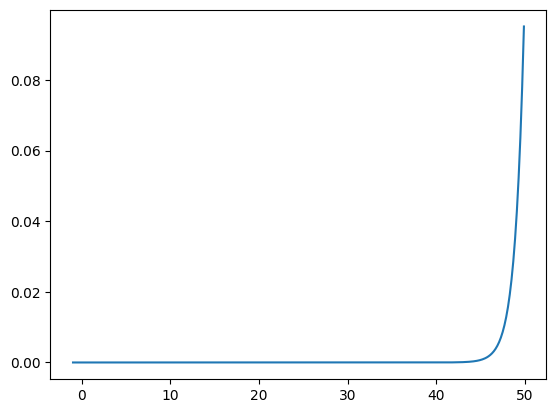

In [364]:
x = np.arange(-1, 50, 0.1)
y = softmax(x)
plt.plot(x, y)

In [365]:
ls ./drive/MyDrive/data/mnistdata/mnist.*

./drive/MyDrive/data/mnistdata/mnist.pkl
./drive/MyDrive/data/mnistdata/mnist.py


In [366]:
from drive.MyDrive.data.mnistdata.mnist import load_mnist

In [367]:
cat ./drive/MyDrive/data/mnistdata/mnist.py

# coding: utf-8
try:
    import urllib.request
except ImportError:
    raise ImportError('You should use Python 3.x')
import os.path
import gzip
import pickle
import os
import numpy as np


url_base = 'http://yann.lecun.com/exdb/mnist/'
key_file = {
    'train_img':'train-images-idx3-ubyte.gz',
    'train_label':'train-labels-idx1-ubyte.gz',
    'test_img':'t10k-images-idx3-ubyte.gz',
    'test_label':'t10k-labels-idx1-ubyte.gz'
}

dataset_dir = os.path.dirname(os.path.abspath(__file__))
save_file = dataset_dir + "/mnist.pkl"

train_num = 60000
test_num = 10000
img_dim = (1, 28, 28)
img_size = 784


def _download(file_name):
    file_path = dataset_dir + "/" + file_name
    
    if os.path.exists(file_path):
        return

    print("Downloading " + file_name + " ... ")
    urllib.request.urlretrieve(url_base + file_name, file_path)
    print("Done")
    
def download_mnist():
    for v in key_file.values():
       _download(v)
        
def _load_label(file_name):
    file_path = data

# MNIST 데이터셋 읽기
```
Parameters
----------
normalize : 이미지의 픽셀 값을 0.0~1.0 사이의 값으로 정규화할지 정한다.
one_hot_label :
    one_hot_label이 True면、레이블을 원-핫(one-hot) 배열로 돌려준다.
    one-hot 배열은 예를 들어 [0,0,1,0,0,0,0,0,0,0]처럼 한 원소만 1인 배열이다.
flatten : 입력 이미지를 1차원 배열로 만들지를 정한다.

Returns
-------
(훈련 이미지, 훈련 레이블), (시험 이미지, 시험 레이블)
```

In [368]:
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=True, normalize=False)

In [369]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [370]:
x_train[0].shape

(784,)

In [371]:
t_train[0]

np.uint8(5)

In [372]:
img = x_train[0].reshape(28, 28)
img.shape

(28, 28)

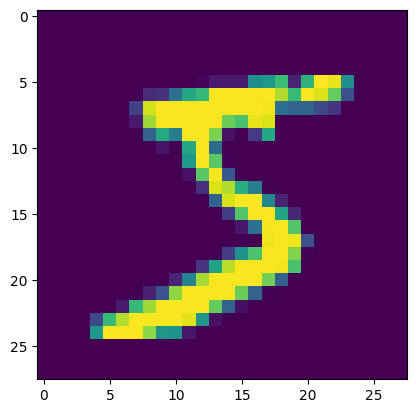

In [373]:
plt.imshow(img)

In [374]:
img = x_train[10].reshape(28, 28)
img.shape

(28, 28)

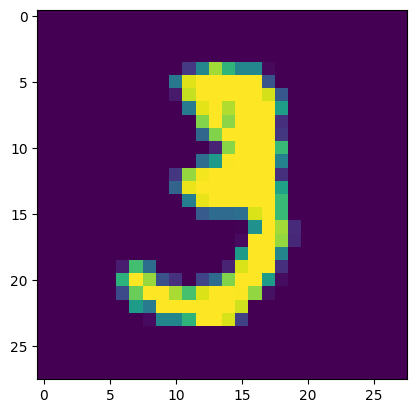

In [375]:
plt.imshow(img)

In [376]:
t_train[10]

np.uint8(3)

In [377]:
import pickle

In [378]:
network = pickle.load(open('./drive/MyDrive/data/mnistdata/sample_weight.pkl', 'rb'))

In [379]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [380]:
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a - c) # 오버플로 대책
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a
    return y

In [381]:
network.keys()

dict_keys(['b2', 'W1', 'b1', 'W2', 'W3', 'b3'])

In [382]:
def predict(network, X):
    W1, W2, W3 = network['W1'], network['W2'], network['W3']
    B1, B2, B3 = network['b1'], network['b2'], network['b3']

    A1 = np.dot(X, W1) + B1
    Z1 = sigmoid(A1)
    A2 = np.dot(Z1, W2) + B2
    Z2 = sigmoid(A2)
    A3 = np.dot(Z2, W3) + B3
    Y = softmax(A3)
    return Y

In [383]:
x_test.shape, network['W1'].shape, network['W2'].shape, network['W3'].shape

((10000, 784), (784, 50), (50, 100), (100, 10))

In [384]:
len(x_test), x_test[0].shape

(10000, (784,))

In [385]:
x_test[0].shape

(784,)

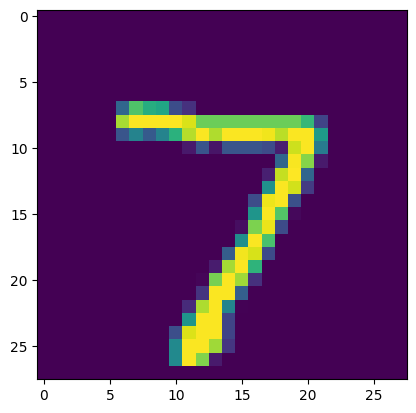

In [386]:
plt.imshow(x_test[0].reshape(28, 28))

In [387]:
np.argmax([1, 4, 2])

np.int64(1)

In [388]:
accuracy_cnt = 0

for i in range(len(x_test)):
    y = predict(network, x_test[i])
    p = np.argmax(y)
    if p == t_test[i]:
        accuracy_cnt += 1

print(accuracy_cnt / len(x_test))

/tmp/ipykernel_11639/1253679003.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


0.9207


In [389]:
x_test.shape

(10000, 784)

In [390]:
y = predict(network, x_test)

/tmp/ipykernel_11639/1253679003.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [391]:
y.shape

(10000, 10)

In [392]:
y_arg = np.argmax(y, axis=1)

In [393]:
y_arg.shape

(10000,)

In [394]:
y_arg[:2]

array([7, 2])

In [395]:
from sklearn.metrics import accuracy_score

In [396]:
accuracy_score(t_test, y_arg)

0.9207

In [397]:
y_0 = predict(network, x_test[0])

/tmp/ipykernel_11639/1253679003.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


In [398]:
y_0

array([4.2879005e-06, 4.5729317e-07, 1.8486280e-04, 8.3605024e-05,
       1.5084674e-07, 6.3182205e-07, 4.5782045e-10, 9.9919468e-01,
       3.8066935e-07, 5.3083024e-04], dtype=float32)

In [399]:
x_test.shape, x_test[0].shape

((10000, 784), (784,))

In [400]:
x_test[0].shape, network['W1'].shape, network['W2'].shape, network['W3'].shape

((784,), (784, 50), (50, 100), (100, 10))

In [401]:
x = x_test
t = t_test

배치 = 하나로 묶은 데이터

수치 계산 라이브러리의 계산 시간을 대폭 줄임

In [402]:
batch_size = 100
accuracy_cnt = 0
for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size] # x[0:100], x[100:200], ...
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])
print('Accuaracy : ', accuracy_cnt / len(x))

/tmp/ipykernel_11639/1253679003.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


Accuaracy :  0.9207


In [403]:
y_batch.shape

(100, 10)

In [404]:
p.shape

(100,)

In [405]:
p[:3]

array([8, 4, 0])

In [408]:
t[i:i+batch_size].shape

(100,)

In [413]:
# 89개 맞았고 11개 틀림
np.sum(p == t[i:i+batch_size]), np.sum(p != t[i:i+batch_size])

(np.int64(89), np.int64(11))

데이터 학습 : 모델을 학습시켜서 가중치를 적절히 선택

적절히 = 손실함수가 최소화 되는 것을 의미
<br>
<br>
신경망 학습에서는 현재의 상태를 '하나의 지표'로 표현,

그 지표를 가장 좋게 만들어주는 가중치 값을 탐색한다.
<br>
<br>
loss function : 신경망 성능의 '나쁨'을 나타내는 지표
    
    - 평균제곱오차

    - 교차 엔트로피 오차

### 평균제곱오차 (mean squared error, MSE)

\begin{equation*}
E = \frac{1}{2} \sum_{k} (y_{k}-t_{k})^{2}
\end{equation*}

$y_k$ 신경망의 출력

$t_k$ 정답 레이블

In [415]:
def mean_squared_error(y, t):
    return 0.5 * np.sum((y-t)**2)

y가 확률이 가장 큰 건 7번째에 있다.

t인 정답에선 1이 2번째에 있다.

=> 오차가 커짐

y가 확률이 가장 큰 건 7번째에 있다.

t인 정답에선 1이 7번째에 있다.

=> 오차가 줄어듬

손실함수가 최소화여야 정답에 가까워진다

In [416]:
# y는 학습된 값 t는 정답지
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

In [419]:
# 정답이 2번째에 있을 때 오차
mean_squared_error(np.array(y), np.array(t))

np.float64(0.5975)

In [420]:
t = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

In [422]:
# 정답이 7번째에 있을 때 오차
mean_squared_error(np.array(y), np.array(t))

np.float64(0.09750000000000003)

### 교차 엔트로피 오차 (cross entropy error, CEE)

$$
E = - \sum_{k} t_k log y_k
$$

log = 밑이 e인 자연로그

$y_k$ 신경망의 출력

$t_k$ 정답 값 (정답에 해당하는 인덱스의 원소만 1인 경우, one-hot 인코딩)

In [423]:
t = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

In [425]:
-np.log(0.6)

np.float64(0.5108256237659907)

In [426]:
-np.log(0.1)

np.float64(2.3025850929940455)

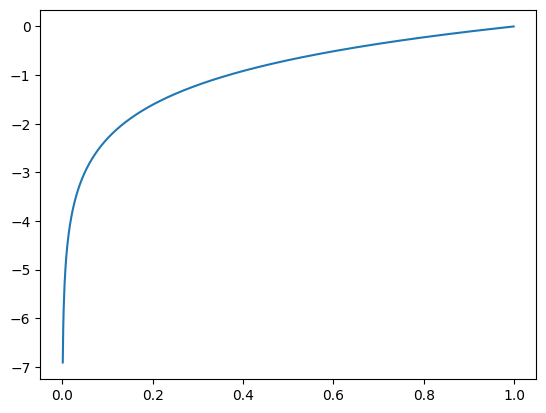

In [429]:
x = np.arange(0.001, 1.0, 0.001)
y = np.log(x)
plt.plot(x, y)

In [432]:
def cross_entropy_error(y, t):
    delta = 1e-7
    return -np.sum(t*np.log(y+delta))

In [437]:
y = np.array([0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0])
t = np.array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [438]:
cross_entropy_error(y, t)

np.float64(2.302584092994546)

In [439]:
t_7 = np.array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [440]:
cross_entropy_error(y, t_7)

np.float64(0.510825457099338)